### Revisão básica de Variáveis complexas
---
O número complexo é amplamente usado na engenharia, assim antes de iniciarmos os estudos faremos uma pequena revisão.

Um número complexo é formado por uma parte real e por uma parte imaginária e geralmente representada pela letra $z$. Uma variável complexa é expressa da seguinte forma:

$$ z = x + yi$$
onde a unidade imaginária as vezes é representada pela letra $j$.

> Algumas Observações:
+ $x:$ é a parte real de $z$, denotada por $Re(z)$.
+ $yi:$ é a parte imaginária de $z$, denotada por $Im(z)$.
+ Propriedade da unidade imaginária: $i^2 = -1$.
+ __Forma Polar:__ $z = re^{iθ} = r(cosθ + isenθ)$, onde $r = |z| = \sqrt{x^2 + y^2}$

Se tomarmos o $θ$ variando no tempo, podemos ter $θ = wt$. Utilizando a identidade de *Euler*, podemos escrever da seguinte forma:

$$ e^{jwt} = (cos(wt) + j sen(wt))$$
Onde podemos retirar as seguintes expressões:
$$cos(wt) = Re(e^{jwt})$$
$$sen(wt) = Im(e^{jwt})$$

### Análise de sinais
---
Essencialmente, um sinal é uma representação matemática de uma variável física que carrega informações sobre um sistema ou processo. A análise de sinais permite extrair informações relevantes desses dados e, assim, entender melhor o comportamento de fenômenos naturais ou artificiais, desenvolver tecnologias de comunicação e aprimorar sistemas de controle e monitoramento.

Os sinais podem ser classificados em várias categorias, sendo as mais comuns os sinais contínuos e os sinais discretos. Sinais contínuos variam de forma contínua ao longo do tempo e são característicos de fenômenos naturais, como ondas de áudio ou eletromagnéticas. Já os sinais discretos são amostragens de sinais contínuos em intervalos específicos de tempo e são amplamente utilizados em sistemas digitais, como computadores e dispositivos de comunicação.

> __Sinais contínuos:__ denonato como x(t), é uma função (real ou complexa) cujo domínio é o conjunto dos reais ℝ. Sinais contínuos representam fenômenos físicos naturais, como som, temperatura e luz, que têm variação contínua em vez de saltos entre valores discretos.

> __Sinais discretos:__ denotado como x[n], é uma função (real ou complexa) cujo domínio é o conjunto dos inteiros 𝒁. Um sinal discreto pode representar um fenômeno para o qual a variável independente é inerentemente discreta. Sinais como dados demográficos são exemplos de tal caso. Por outro lado, uma classe muito importante de sinais de tempo discreto decorre da amostragem de sinais de tempo contínuo.


In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from cupyx.scipy.fft import fft, fftshift, fftfreq
from sympy import Heaviside, sympify

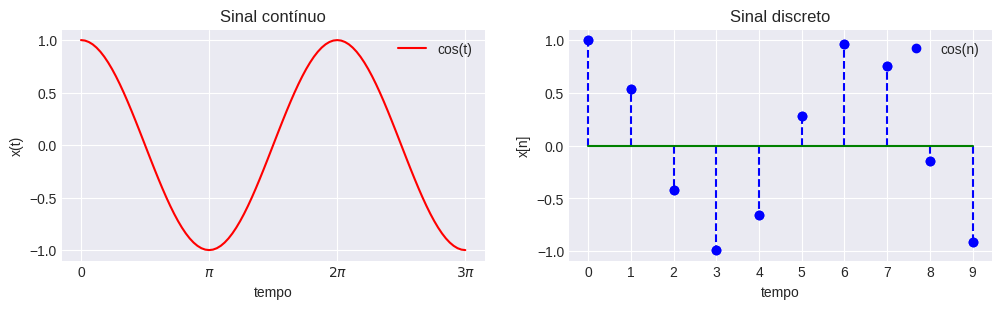

In [ ]:
t = np.linspace(0, 3*np.pi, 100)
n = np.arange(0, 3*np.pi, 1)
x = np.cos(t)
y = lambda n: np.cos(n)

# Configurando o gráfico.
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize = (12,3))

# Sinal continuo
axis[0].plot(t, x, color = "red", label = "cos(t)")
axis[0].set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi], [r'0', r'$\pi$', r'$2\pi$', r'$3\pi$'])
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("x(t)")
axis[0].set_title("Sinal contínuo")
axis[0].legend(loc = "best")

# Sinal discreto
axis[1].plot(n, y(n), "o", color = "blue", label = "cos(n)")
axis[1].stem(n, y(n), linefmt='b--', basefmt='g-')
axis[1].set_xticks(np.arange(0, 3*np.pi, 1))
axis[1].set_xlabel("tempo")
axis[1].set_ylabel("x[n]")
axis[1].set_title("Sinal discreto")
axis[1].legend(loc = "best")

plt.show()

No primeiro subplot, apresentamos um gráfico senoidal que é perfeito para ilustrar um sinal contínuo. Ele mostra a distribuição cossenoidal do sinal ao longo do tempo $t$, permitindo que a forma da onda completa seja claramente observada. Esse sinal varia continuamente no intervalo de $[0,3π]$. No segundo subplot, utilizamos `axis[1].stem`, que gera um gráfico com hastes. Esse tipo de gráfico é perfeito para ilustrar como funciona um sinal discreto, pois destaca que o sinal existe apenas em pontos específicos. Isso é especialmente útil para mostrar sinais amostrados ou sequências numéricas.

Esses gráficos possibilitam uma comparação direta entre a representação contínua e a discreta. Eles oferecem uma visualização clara e didática, facilitando a compreensão da transição de um sinal contínuo para o discreto.

### Manipulações com sinais periódicos
Um sinal periódico de tempo contínuo $x(t)$ tem a propriedade de que existe um valor positivo T para o qual $x(t) = x(t + T)$ para todos os valores de $t$. Em outras palavras, um sinal periódico tem a propriedade de não se modificar pelo deslocamento no tempo de $T$.

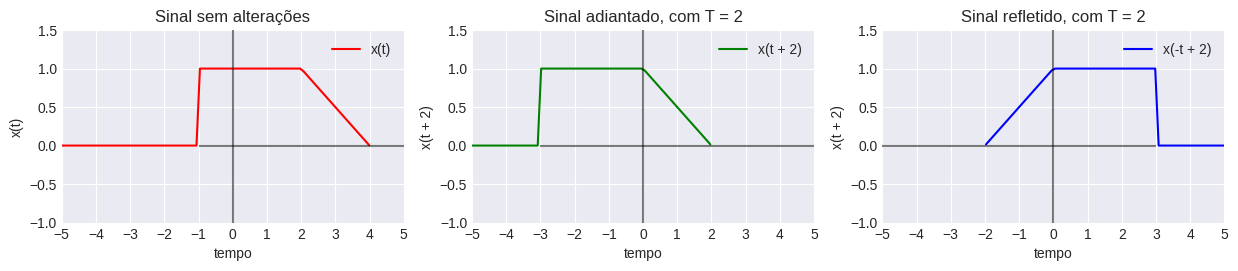

In [ ]:
def x(t):
    if t < -1:
        return 0
    elif(t <= 2):
        return 1
    elif(t <= 4):
        return 2 - 0.5 * t

t = np.linspace(-5, 5, 100)

fig, axis = plt.subplots(1, 3, figsize = (15, 2.5))

# Sinal sem alterações
axis[0].plot(t, list(map(x, t)), color = "red", label = "x(t)")
axis[0].axis([-5, 5, -1, 1.5])
axis[0].set_xticks(np.arange(-5, 6, 1))
axis[0].hlines(0, -1, 5, 'k', alpha=0.5)
axis[0].vlines(0, -1, 1.5, 'k', alpha=0.5)
axis[0].set_title("Sinal sem alterações")
axis[0].legend(loc = "best")
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("x(t)")

# Sinal adiantado, com T = 2
axis[1].plot(t, list(map(x, t + 2)), color = "green", label = "x(t + 2)")
axis[1].axis([-5, 5, -1, 1.5])
axis[1].set_xticks(np.arange(-5, 6, 1))
axis[1].hlines(0, -3, 5, "k", alpha = 0.5)
axis[1].vlines(0, -1, 1.5, "k", alpha = 0.5)
axis[1].set_title("Sinal adiantado, com T = 2")
axis[1].set_xlabel("tempo")
axis[1].set_ylabel("x(t + 2)")
axis[1].legend(loc = "best")

# Sinal refletido, com T = 2
axis[2].plot(t, list(map(x, -t + 2)), color = "blue", label = "x(-t + 2)")
axis[2].axis([-5, 5, -1, 1.5])
axis[2].set_xticks(np.arange(-5, 6, 1))
axis[2].hlines(0, -5, 3, "k", alpha = 0.5)
axis[2].vlines(0, -1, 1.5, "k", alpha = 0.5)
axis[2].set_title("Sinal refletido, com T = 2")
axis[2].set_xlabel("tempo")
axis[2].set_ylabel("x(t + 2)")
axis[2].legend(loc = "best")

plt.show()

### Conclusão:
Este exemplo acima nos permitiu visualizar de forma prática como sinais podem ser deslocados e refletidos. A comparação lado a lado entre o sinal original e suas transformações fez com que ficasse claro o impacto dessas operações no comportamento dos sinais. Ao visualizar essas mudanças, conseguimos apreciar melhor as propriedades dos sinais e como elas se relacionam com o tempo.

### Funções de impluso unitário e degrau unitário
---
As funções de degrau unitário e impulso unitário são fundamentais na análise de sinais e sistemas, servindo como ferramentas essenciais para entender e modelar comportamentos dinâmicos. O degrau unitário, frequentemente denotado por $u[n]$ no domínio discreto e $u(t)$ no domínio contínuo, desempenha um papel crucial na representação de sinais que iniciam em um determinado instante de tempo.

$$
u[n] =
\begin{cases}
    0, & \text{se } n < 0 \\
    1, & \text{se } n \geq 0
\end{cases}
\quad \quad \quad
u(t) =
\begin{cases}
    0, & \text{se } t < 0 \\
    1, & \text{se } t \geq 0
\end{cases}
$$

Por outro lado, a função impulso unitário, denotada como $δ[n]$ para o tempo discreto e $δ(t)$ para o tempo contínuo, representa uma ação instantânea e é a base para a análise de sistemas lineares.

$$
δ[n] =
\begin{cases}
    0, & \text{se } n \neq 0 \\
    1, & \text{se } n = 0
\end{cases}
\quad \quad \quad
δ(t) =
\begin{cases}
    ∞, & \text{se } t = 0 \\
    0, & \text{se } t \neq 0
\end{cases}
$$

É possível afirmar que a função impulso unitário pode ser considerada a derivada da função degrau unitário em relação ao tempo.
$$\begin{equation}
δ(t) = \frac{du(t)}{dt}
\end{equation}
$$
Temos também a seguinte propriedade:
$$
\begin{equation}
  \int_{-∞}^{∞} δ(τ)\,dτ = 1
\end{equation}
$$


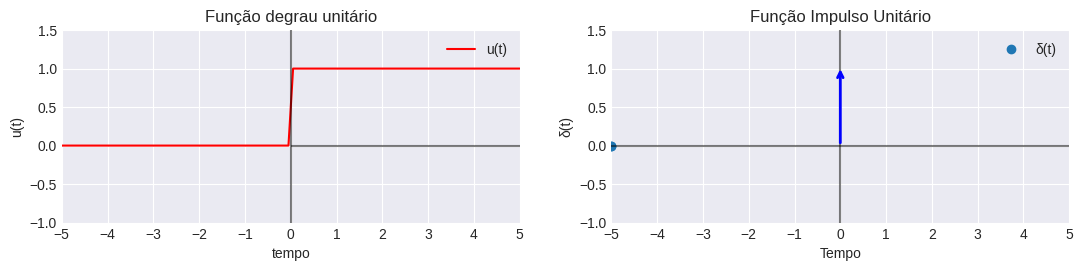

In [ ]:
def u(t):
    if t < 0:
        return 0
    else:
        return 1

t = np.linspace(-5, 5, 100)
t_delta = np.linspace(-5, 5, 1)

# Configurando gráficos.
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize = (13,2.5))

# Gráfico da função degrau unitário.
axis[0].plot(t, list(map(u, t)), color = "red", label = "u(t)")
axis[0].axis([-5, 5, -1, 1.5])
axis[0].set_xticks(np.arange(-5, 6, 1))
axis[0].hlines(0, 0, 5, 'k', alpha=0.5)
axis[0].vlines(0, -1, 1.5, 'k', alpha=0.5)
axis[0].set_title("Função degrau unitário")
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("u(t)")
axis[0].legend(loc = "best")

# Gráfico da função impulso unitário.
impulse = np.zeros_like(t_delta)
impulse[t_delta == 0] = 1
axis[1].plot(t_delta, impulse, "o", label="δ(t)")
axis[1].stem(t_delta, impulse)
# Adicionando uma seta para cima
axis[1].annotate('', xy=(0, 1.03), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axis[1].axis([-5, 5, -1, 1.5])
axis[1].set_xticks(np.arange(-5, 6, 1))
axis[1].hlines(0, -5, 5, 'k', alpha=0.5)
axis[1].vlines(0, -1, 1.5, 'k', alpha=0.5)
axis[1].set_title("Função Impulso Unitário")
axis[1].set_xlabel("Tempo")
axis[1].set_ylabel("δ(t)")
axis[1].legend(loc = "best")

plt.show()

A multiplição de uma função por impluso pode ser definida por:
$$\begin{equation}
x(t)δ(t - t_o) = x(t_o) δ(t - t_o)
\end{equation}$$

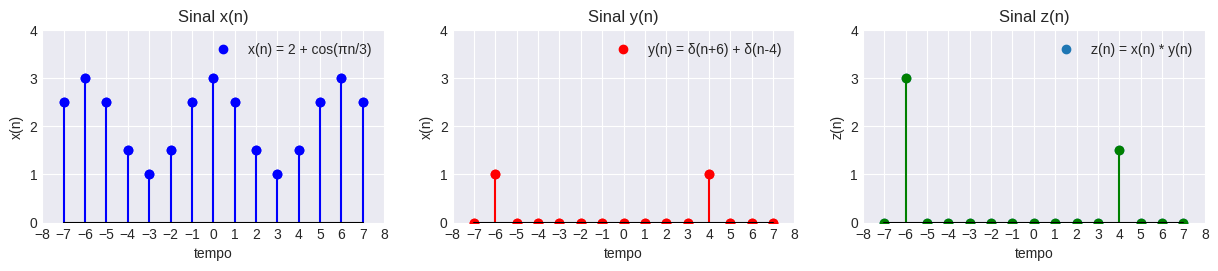

In [ ]:
# Definindo os valores de n.
n = np.arange(-7, 8, 1)

# Definindo o sinal x(n).
x = lambda n : 2 + np.cos((np.pi * n) / 3)

# Definindo o sinal y(n) com função delta.
y = np.zeros_like(n)
# Definindo os valores de picos.
y[n == -6] = 1
y[n == 4] = 1

# Realizando a multiplicação dos sinais
z = lambda n : x(n) * y

# Plotando os gráficos
fig, axis = plt.subplots(1, 3, figsize=(15, 2.5), sharex=True)

# Gráfico de x(n)
axis[0].plot(n, x(n), "o", color = "blue", label='x(n) = 2 + cos(πn/3)')
axis[0].stem(n, x(n), linefmt='b-', markerfmt='bo', basefmt='k')
axis[0].axis([-8, 8, 0, 4])
axis[0].set_xticks(np.arange(-8, 9, 1))
axis[0].set_title("Sinal x(n)")
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("x(n)")
axis[0].legend(loc='best')

# Gráfico de y(n)
axis[1].plot(n, y, "o", color = "red", label='y(n) = δ(n+6) + δ(n-4)')
axis[1].stem(n, y, linefmt='r-', markerfmt='ro', basefmt='k')
axis[1].axis([-8, 8, 0, 4])
axis[1].set_xticks(np.arange(-8, 9, 1))
axis[1].set_title("Sinal y(n)")
axis[1].set_xlabel("tempo")
axis[1].set_ylabel("x(n)")
axis[1].legend(loc='best')

# Gráfico gerado pela multiplicação: z(n) = x(n) * y(n)
axis[2].plot(n, z(n), "o", label='z(n) = x(n) * y(n)')
axis[2].stem(n, z(n), linefmt='g-', markerfmt='go', basefmt='k')
axis[2].axis([-8, 8, 0, 4])
axis[2].set_xticks(np.arange(-8, 9, 1))
axis[2].set_title("Sinal z(n)")
axis[2].set_xlabel("tempo")
axis[2].set_ylabel("z(n)")
axis[2].legend(loc='best')


plt.show()


Neste exemplo criamos uma sequência $x_n$  que é uma função cosseno modificada, colocamos um sinal com amplitude igual a 1 nos picos em $n = -6$ e $n = 4$ para representar as funções delta e  realizamos a multiplicação ponto a ponto entre $x(n)$ e $y(n)$, resultando em $z(n)$.
 $$x(t) = 2 + cos(\frac{π*n}{3}) \quad y(t) =  δ(n + 6) + δ(n - 4)$$
 Após a multiplicação encontramos a exepressão para $z(n)$:
 $$z(n) = x(-6)δ(n + 6) + x(4)δ(n - 4)$$
 De forma geral para tempo discreto:
$$
\begin{equation}
x(n) =
  \sum_{k=-∞}^{∞} x(k)δ(n - k)
\end{equation}$$
Já para o tempo contínuo temos:
$$
\begin{equation}
x(t) =
  \int_{-∞}^{∞} x(τ)δ(t - τ)dτ
\end{equation}
$$

### Análise de sistemas
---
Esses sistemas são fundamentais em processamento de sinais, pois muitos algoritmos de equalização, assumem linearidade e invariância no tempo para simplificar a modelagem.
> Os sistemas podem ser classificados de acordo com suas propriedades:

+ __Memória:__ Um sistema é dito sem memória se a saída em qualquer instante depende apenas da entrada naquele instante de tempo.
+ __Invertibilidade:__ Um sistema que possui entradas distintas correspodentes a saídas distintas, isso significa que podemos encontrar sua entrada a partir de sua saída.
+ __Causalidade:__ Um sistema em que sua saída $y(t)$ depende das amostras presentes e ou passadas da entrada:
  - Exemplo de sistema causal: $y(t) = cos(t + 1)x(t)$
  - Exemplo de sistema não causal: $y(n) = x(-t) => y(-2) = x(2)$
+ __Estabilidade:__ Um sistema em que toda sequência de entrada limitada produz uma saída também limitada.
  - Exemplo de sistema estável: $\begin{equation}
  y[n] = \sum_{k = -m}^{m} x(n - k)
  \end{equation}$
  - Exemplo de sistema não estável: $\begin{equation}
  y[n] = \sum_{k = -∞}^{n} x(k)
  \end{equation}$
+ __Invariante no tempo ou deslocamento:__ Se o comportamento e as caracteristicas são fixos ao longo do tempo. Um deslocamento no tempo no sinal de entrada resulta num deslocamento no tempo de saída.
 - Se: $y[n] = T[x(n)]$ , então: $y[n - n_o] = T[x(n - n_o)]$
+ __Linearidade:__ é um sistema que tem a importante propriedade da superposição, ou seja, deve satisfazer a $aditividade$ e $homogeneidade$:
  - Dados: $y_1(t) = T[x_1(t)]$ e $y_2(t) = T[x_2(t)]$
  - $Aditividade:$ $T[x_1(t) + x_2(t)] = y_1(t) + y_2(t)$
  - $homogeneidade:$ $T[ax_1(t)] = a y_1(t)$
  - Se a entrada for zero a saída também será zero.

### Sistema Linaear e Invariante ao tempo __(LTI)__
---
+ __Resposta ao impulso:__ A resposta ao impulso $h(t)$ é aplicado na entrada de sistema linear e invariante ao tempo __(LTI)__.
$$ Sistema \quad LTI $$
$$ \quad δ(t) \quad = = > \quad T [\quad ]  \quad = = > h (t)$$
$$ou$$
$$ \quad δ(n) \quad = = > \quad T [\quad ]  \quad = = > h (n)$$
+ __Convolução Discreta:__ A saída de um sistema __(LTI)__ pode ser sempre obtida através da relação de convolução entre a entrada e a resposta ao impulso do sistema.
$$\begin{equation}
y(t) = h(t) * x(t) \quad ou \quad y(n) = h(n) * x(n)
\end{equation}$$
 - __Integral da convolução:__
  $$ \begin{equation}
  a(t) * b(t) =
    \int_{-\infty}^{\infty} a(τ)b(t - \tau)d(\tau)
  \end{equation}$$
  - __Somatório da convolução:__
  $$\begin{equation}
  y(n) =
    \sum_{k = -\infty}^{\infty} x(k).h(n - k)
  \end{equation}$$
  - __Propriedades da convolução:__
    - $Comutativa:$ $x(n) * h(n) = h(n) * x(n)$
    - $Distributiva:$ $y(n) = x(n) * [h_1(n) + h_2(n)]$
    - $Associativa:$ $y(n) = x(n) * [h_1(n) * h_2(n)]$

### Exemplo 1:
Determinar a resposta do sistema quando:
+ $x(t) = e^{-at}u(t), a > 0$
+ $h(t) = u(t)$

In [ ]:
# Gerando o sinal h(t)
def u(t):
  if t < 0:
    return 0
  else:
    return 1

# Gerando o sinal x(t) = e^(-at)u(t)
def x(t, a):
  if t < 0:
    return 0
  elif t == 0:
    return 1
  else:
    return np.exp(-a * t) * u(t)

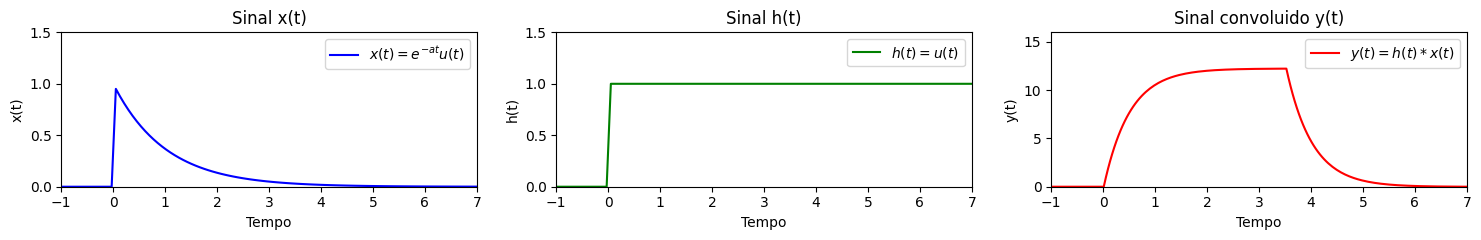

In [ ]:
# Definindo os valores de t para a plotagem
t = np.linspace(-1, 7, 100)

# Definindo um valor para a
a = 1

# Gerando os sinais x(t) e h(t) para os valores de t
x_t = list(map(lambda t: x(t, a), t))
h_t = [u(ti) for ti in t]

# Gerando a convolução do sinal
y_t = np.convolve(x_t, h_t, mode='full')
t_conv = np.linspace(-1, 7, len(y_t))

# Plotando os gráficos
fig, axis = plt.subplots(1, 3, figsize=(15, 2.5))

# Gráfico de x(t)
axis[0].plot(t, x_t, color="blue", label='$x(t) = e^{-at}u(t)$')
axis[0].axis([-1, 7, 0, 1.5])
axis[0].set_xticks(np.arange(-1, 8, 1))
axis[0].set_title("Sinal x(t)")
axis[0].set_xlabel("Tempo")
axis[0].set_ylabel("x(t)")
axis[0].legend(loc='best')

# Gráfico de h(t)
axis[1].plot(t, h_t, color="green", label='$h(t) = u(t)$')
axis[1].axis([-1, 7, 0, 1.5])
axis[1].set_xticks(np.arange(-1, 8, 1))
axis[1].set_title("Sinal h(t)")
axis[1].set_xlabel("Tempo")
axis[1].set_ylabel("h(t)")
axis[1].legend(loc='best')

# Gráfico de y(t)
axis[2].plot(t_conv, y_t, color="red", label='$y(t) = h(t) * x(t)$')
axis[2].axis([-1, 7, 0, 16])
axis[2].set_xticks(np.arange(-1, 8, 1))
axis[2].set_title("Sinal convoluido y(t)")
axis[2].set_xlabel("Tempo")
axis[2].set_ylabel("y(t)")
axis[2].legend(loc='best')

plt.tight_layout()
plt.show()


## Transformada de Fourier
---
A Transformada de Fourier é uma ferramenta matemática poderosa que nos permite decompor um sinal em suas componentes de frequência. Em outras palavras, ela "divide" um sinal complexo em uma soma de ondas sinusoidais mais simples, cada uma com sua própria frequência, amplitude e fase. A Série de Fourier se baseia na ideia de que qualquer função periódica $f(t)$, sob certas condições, pode ser expressa como uma soma de senos e cossenos.

> Representação de sinais periódicos, com período $T_0$, como uma soma ponderada de sinais senoidais.

$$\begin{equation}
x(t) = a_0 +
  \sum_{n=1}^{\infty} [a_n cos(n\omega_0t) + b_n sen(n\omega_0t)]
\end{equation}$$

A principal vantagem da Série de Fourier é a capacidade de simplificar cálculos. Em vez de tratar o sinal completo e suas variações complexas ao longo do tempo, ele pode ser expresso em termos de suas componentes harmônicas, facilitando a análise e o design de sistemas. Essa decomposição também é fundamental para técnicas de modulação e demodulação, cancelamento de ruído e equalização em sistemas de comunicação.

Onde as constantes podem ser definidas quando $x(t)$ um sinal periódico, com período fundamental $T_0$.
  + $\omega_0 = \frac{2\pi}{T_0}$
  + __Média do sinal:__  $ a_0 = \frac{1}{T_0} \int_{<T_0} x(t) $
  + $a_n = \frac{2}{T_0} \int_{<T_0>} x(t) cos(n\omega_0t)dt$
  + $b_n = \frac{2}{T_0} \int_{<T_0>} x(t) sen(n\omega_0t)dt$  
  
$$ Sistema \quad LTI$$
$$\quad x(t) = \sum_{k} a_ke^{jω_kt} \quad ⟹\quad [\quad h(n)\quad ]
\quad ⟹ \quad y(n) = \sum_{k} a_ke^{jω_kt}.H(ω_k)$$

$$\begin{equation}
H(ω_k) = \int_{-∞}^{∞} h(t)e^{-jω_kt} dt
\end{equation}$$

> __Série de fourier para sinais contínuos e periódicos:__

$x(t)$ um sinal priódico, com período fundamental $T_0$ e frequência fundamental $ω_0 = 2π/T_0$:
$$\begin{equation}
x(t) = \sum_{k = -\infty}^{\infty} a_ke^{jkω_0t}
\end{equation}$$
$$\begin{equation}
a(k) = \frac{1}{T_0} \int_{<T_0>} x(t)e^{-jkω_0t}d(t)
\end{equation}$$

### Exempo 2
---
Vamos implementar um código em Python para calcular $x(t)$ com diferentes valores de $N$ (número de termos harmônicos da série). A ideia é observar como o sinal se aproxima de uma onda quadrada conforme aumentamos N , assim como mostrado acima.

In [ ]:
class FourierSeries:
    def __init__(self, T0):
        # Parâmetros do sinal
        self.T0 = T0
        self.w0 = 2 * cp.pi / T0

    def a_k(self, k):
        # Calcula o coeficiente a_k da série de Fourier.
        # A expressão de a_k foi calculada antes manualmente.
        if k == 0:
            return 0.5
        else:
            return cp.sin(k * cp.pi / 2) / (k * cp.pi)

    def x_t(self, t, N):
        # Calcula x(t) usando a série de Fourier truncada em N1.
        # Criando matriz complexa do tipo de t.
        result = cp.zeros_like(t, dtype=cp.complex_)
        for k in range(-N, N + 1):
            result += self.a_k(k) * cp.exp(1j * k * self.w0 * t)
        return cp.real(result)

    def signal(self, t):
        # Gera o sinal quadrado original
        return np.where(((t + 0.5)% self.T0) < (self.T0 / 2 ), 1, 0)

    def plot(self, t, N_values):
        # Plota x(t) para diferentes valores de N.
        # Configurando os gráficos.
        fig, axes = plt.subplots(1, len(N_values), figsize=(18, 3))
        fig.subplots_adjust(left=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)

        for i, N in enumerate(N_values):
            # Gerando os valores de x(t) para o valor de N.
            if N == 0:
                x_t = self.signal(t)
                axes[i].set_title(f'Sinal Original')
            else:
              x_t = self.x_t(t, N)
              axes[i].set_title(f'$x_{{N}}(t)$ para $N = {N}$')
            # Transformando os valores de x(t) e t que estão em cupy para numpy.
            xn = x_t.get()
            tn = t.get()
            # Plotando os gráficos.
            axes[i].plot(tn, xn, color='red', label=f'$N_1 = {N}$')
            axes[i].axis([-3, 3, -0.2, 1.4])
            axes[i].set_xlabel('tempo')
            axes[i].set_ylabel('$x_{N}(t)$')
            axes[i].grid(True)
            axes[i].legend(loc = "best")

        plt.show()

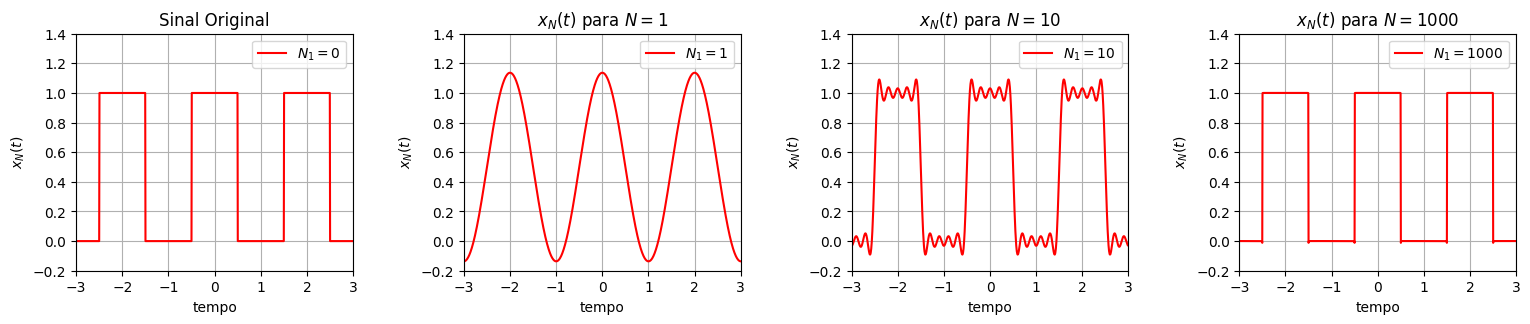

In [ ]:
# Parâmetros do sinal
T0 = 2
t = cp.linspace(-3, 3, 1000)
# Valores para a série de Fourier da k-ésima harmonica.
N_values = [0, 1, 10, 1000]

# Instanciando a classe e plotando
fourier_series = FourierSeries(T0)
fourier_series.plot(t, N_values)

### Transformada de Fourier para sinais contínuos
---
> __Transformada de fourier para sinais contínuos e não-periódicos:__

Um sinal periódico $x_p(t)$ com período $T_0$ podem ser representados por uma série de *Fourier*, mas caso admitirmos $T_0 = ∞$, teremos um sinal não-periódico e assim: $x_p(t) = x(t) \quad e \quad k\omega_0 = \omega$. Então as ficam assim:
$$\begin{equation}
x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega)e^{jωt} d\omega
\quad \quad
X(\omega) = \int_{-\infty}^{\infty} x(t)e^{-jωt} d\omega
\end{equation}$$

+ __X(ω):__ Transformada de Fourier de $x(t).$
+ __X(ω):__ Espectro $x(t)$.
+ __x(t):__ Transformada inversa de Fourier de $X(\omega)$

A Equação de síntese $x(t)$ desempenha um papel para os sinais
aperiódicos, pois representa um sinal como uma combinação linear de exponenciais complexas. Em analogia com a terminologia usada para os coeficientes da série de Fourier de um sinal periódico, a transformada $X(ω)$ de um sinal aperiódico $x(t)$ normalmente é conhecida como o espectro de $x(t)$,
pois nos fornece informações necessárias para descrever $x(t)$ como uma combinação linear de sinais senoidais em diferentes frequências.

> __Transformada de fourier para sinais contínuos e periódicos?__

Vimos anteriormente que os sinais contínuos e periódicos podem ser representados pela série de Fourier. Mas eles também possuem transformada?
Para isso, vamos analisar o seguinte exemplo:
$$\begin{equation}
X(\omega) = 2\pi\delta(\omega - \omega_0)
\end{equation}$$
Sua transformada inversa pode ser definada como:
$$
x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega)e^{jωt} d\omega = \
\frac{1}{2\pi} \int_{-\infty}^{\infty} 2\pi\delta(\omega - \omega_0) e^{jωt}d\omega
$$
Vimos anteriormente que:
$$
x(t)δ(t - t_o) = x(t_o) δ(t - t_o) \ ==> \
e^{jωt}δ(ω - ω_0) = e^{jω_0t}δ(ω - ω_o)
$$
assim:
$$\begin{equation}
x(t) = e^{jω_0t} \int_{-\infty}^{\infty} \delta(\omega - \omega_0)d\omega \ = \
e^{jω_0t}
\end{equation}$$
Deste modo, conseguimos encontrar uma tranformada de Fourier para sinais periódicos:
$$\begin{equation}
x(t) = \sum_{k = -\infty}^{\infty} a_ke^{jkω_0t} \
\end{equation}$$
$$\begin{equation}
X(ω) = 𝓕(\sum_{k = -\infty}^{\infty} a_ke^{jkω_0t}) = \
\sum_{k = -\infty}^{\infty} a_k𝓕(e^{jkω_0t}) = \
\sum_{k = -\infty}^{\infty} a_k 2\pi\delta(\omega - \omega_0)
\end{equation}$$

> Potanto, temos as seguintes equações da Transformada de Fourier para sinais periódicos:
> + __Equação síntese:__  $x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega)e^{jωt} d\omega $
> + __Equação Analise:__ $X(\omega) = \sum_{k = -\infty}^{\infty} a_k 2\pi\delta(\omega - \omega_0)$

Segue link para visualizar um exemplo mais detalhado da tranformada de Fourier:
 [https://github.com/Medupl/.../Numpy_Opticas.ipynb](https://github.com/Medupl/PIBITI/blob/main/Capacitacao/Numpy/Numpy_Opticas.ipynb)

 ### Propriedade da convolução
 ---
Como a resposta ao impulso da cascata de dois sistemas LIT é a convolução
das respostas ao impulso individuais, a propriedade de convolução implica que a resposta em frequência total da cascata de dois sistemas é simplesmente o produto das respostas em frequências individuais.

$$\quad x(t)\quad ⟹ \quad [\quad h(t)\quad ]\quad ⟹ \quad y(t) = x(t) * h(t)$$
$$\quad X(ω)\quad ⟹ \quad [\quad h(t)\quad ]\quad ⟹ \quad  Y(ω) = X(ω).H(ω)$$
+ $H(ω) = 𝓕[{h(t)}]$ - Resposta em frequência de um sistema **LTI**

### Transformada de Fourier para sinais discretos
---
Relembrando:
$$Sistema \quad LTD$$
$$\quad x(n)\quad ⟹\quad [\quad h(n)\quad ]\quad ⟹ \quad y(n) = x(n)*h(n)$$
+ $y(t) = \sum_{k = -∞}^{∞} = x(k) h(n - k )$
+ Se $x(n) = e^{jΩ_0n}:  y(n) = e^{jΩ_0n}H(Ω_0)$
+ $ H(Ω) = \sum_{k = -∞}^{∞} = x(n) e^{-jΩn}$

> __Série de fourier para sinais no tempo discreto:__

Em particular, a representação em série de Fourier de um sinal periódico
de tempo discreto é uma série finita, ao contrário da representação em série infinita exigida para os sinais periódicos de tempo contínuo.
A série de fourier descreve com um sinal periódico, com **N** períodos, pode ser mostrada como uma soma de *N* exponenciais complexas, assim:
$$\begin{equation}
x(n) = \sum_{n = <N>} a_ke^{jk\frac{2π}{N}n}
\end{equation}$$
$$\begin{equation}
a(k) = \frac{1}{N} \sum_{n = <N>}x(n)e^{-jk\frac{2π}{N}n}
, \text{onde $k = a_k + Nr , \quad r \quad ϵ \quad ℤ$}
\end{equation}$$

> __Transformada de fourier para sinais discretos e não-periódicos:__

Semelhante ao que acontece com sinais contínuos, na síntese da série de Fourier de tempo discreto que envolve uma soma finita e, consequentemente,
também não tem problemas de convergência a ela associados. Em particular, se aproximarmos um sinal aperiódico x[n] por uma integral de exponenciais complexas com frequências tomadas do intervalo |ω| ≤ W, ou seja,

$$\begin{equation}
x(n) = \frac{1}{2\pi} \int_{2\pi} X(\Omega)e^{jΩn} d\Omega
\quad \quad
X(\Omega) = \sum_{n = -\infty}^{\infty} x(n)e^{-jΩn}
\end{equation}$$
+ $X(Ω):$ Sinal contínuo e periódico com período de $2\pi$

Através dessas fórmulas, podemos demostrar que:
> $$ x(n) = e^{jΩ_0n} \quad = = > \quad X(Ω) = 2\piδ(Ω - Ω_0 - 2\pi m)$$
Este sinal pode ser periódico ou não.

> __Transformada de fourier para sinais discretos e periódicos:__

Em tempo contínuo, vimos que a transformada de Fourier de $e^{jω_0t}$ pode ser interpretada como um impulso em $ω = ω_0$. Portanto, podemos esperar o mesmo tipo de transformada para o sinal de tempo discreto $ x(n) = e^{j\omega_0n}$

Para sinais priódicos temos:
$$\begin{equation}
x(n) = \frac{1}{2\pi} \int_{2\pi} X(\Omega)e^{jΩn} d\Omega
\quad \quad
X(\Omega) = \sum_{k = -\infty}^{\infty} 2\pi a_k\delta (Ω - \frac{2kπ}{N})
\end{equation}$$

> __Observações:__
> + Analise do sinal após as transformações em tempo contínuo:
    - *Série de Fourier:* discreta e aperiódica.
    - *Tranformada de Fourier:* contínua e aperiódica.
> + Analise do sinal após as transformações em tempo discreto:
    - *Série de Fourier:* discreta e periódica.
    - *Tranformada de Fourier:* contínua e periódica.

 ### Propriedade da convolução
 ---
Acontece algo semelhante a propriedade de convolução no tempo contínuo, e esse é um dos principais motivos para a transformada de Fourier de tempo discreto ser de grande valor na representação e análise de sistemas LIT de tempo discreto. Especificamente, se x[n], h[n] e y[n] forem a entrada, resposta ao impulso e saída,respectivamente, de um sistema LIT, de modo que:

$$\quad x(n)\quad = = >\quad [\quad h(n)\quad ]\quad = = > y(n) = x(n) * h(n)$$
$$\quad X(Ω)\quad = = >\quad[\quad h(n)\quad ]\quad = = > Y(Ω) = X(Ω).H(Ω)$$

+ $H(Ω) = 𝓕[{h(n)}]$ - Resposta em frequência de um sistema **LTD**

Um sistema só possui resposta em frequência se for estável. Para sistemas instáveis usamos a $transformada \quadℤ$ .

### Exemplo 3
---
Vamos gerar uma sa´da, onde um sinal $x(n)= \frac{4sin(πn/4)}{πn}$ modulando uma portadora $cos(Ω_cn)$, onde $Ω_c=π/2$, vamos criar um código em Python usando bibliotecas como cupy para cálculos e matplotlib para visualização. O código calculará e plotará os gráficos do sinal $x(n)$, seu espectro $X(Ω)$, o sinal modulado $y(n)=x(n)cos(Ω_cn)$, e o espectro modulado $Y(Ω)$.

In [ ]:
# Parâmetros do sinal
n = cp.arange(-1000, 1000, 1)
omega_c = cp.pi / 2
T = n[1] - n[0]
freq = fftshift(fftfreq(len(n), T)) * 2 * cp.pi

# Definindo o sinal x(n)
x_n =  4 * cp.sinc(n / 4)

# Sinal y(n) = x(n) * cos(omega_c * n)
y_n = x_n * cp.cos(omega_c * n)

# Calculando os espectros X(w) e Y(w) e deslocando para a frequencia zero para o centro.
X_w = fft(x_n)
X_w = cp.abs(fftshift(X_w))

Y_w = fft(y_n)
Y_w = cp.abs(fftshift(Y_w))

# Normalizando os espectros para amplitude máxima 4
X_w *= 4 / cp.max(X_w)
Y_w *= 4 / cp.max(Y_w)

# Transferindo os dados para a cpu para plotagem
n = n.get()
x_n = x_n.get()
y_n = y_n.get()
freq = freq.get()
X_w = X_w.get()
Y_w = Y_w.get()

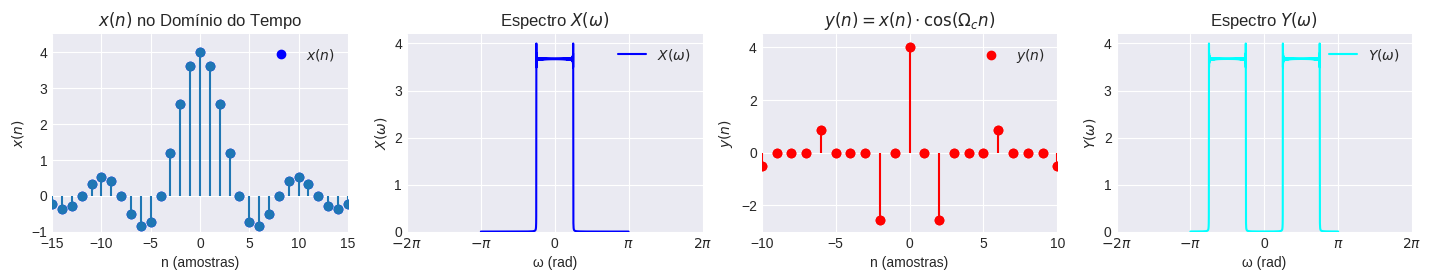

In [ ]:
# Plotando os gráficos
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 4, figsize=(17, 2.5))
fig.subplots_adjust(left=0.1, right=0.9, top=0.9)

# Sinal x(n) no domínio do tempo
axes[0].plot(n, x_n, "o", color='blue', label='$x(n)$')
axes[0].stem(n, x_n, basefmt=" ")
axes[0].axis([-15, 15, -1, 4.5])
axes[0].set_xlabel('n (amostras)')
axes[0].set_ylabel('$x(n)$')
axes[0].set_title('$x(n)$ no Domínio do Tempo')
axes[0].legend(loc='best')

# Espectro X(ω)
axes[1].plot(freq, X_w, color='blue', label = '$X(ω)$')
axes[1].set_xlim(-2 * cp.pi, 2 * cp.pi)
axes[1].set_ylim(0, 4.2)
axes[1].set_xticks([-2 * cp.pi, -cp.pi, 0, cp.pi, 2 * cp.pi])
axes[1].set_xticklabels(['$-2\pi$', '$-\pi$', '0', '$\pi$', '$2\pi$'])
axes[1].set_xlabel('ω (rad)')
axes[1].set_ylabel('$X(ω)$')
axes[1].set_title('Espectro $X(ω)$')
axes[1].legend(loc='best')

# Sinal y(n) no domínio do tempo
axes[2].plot(n, y_n, "o", color='red', label='$y(n)$')
axes[2].stem(n, y_n, basefmt=" ", linefmt="r-", markerfmt="ro")
axes[2].axis([-10, 10, -3, 4.5])
axes[2].set_xlabel('n (amostras)')
axes[2].set_ylabel('$y(n)$')
axes[2].set_title('$y(n) = x(n) \cdot \cos(Ω_c n)$')
axes[2].legend(loc='best')

# Espectro Y(ω)
axes[3].plot(freq, Y_w, color='cyan', label='$Y(ω)$')
axes[3].set_xlim(-2 * cp.pi, 2 * cp.pi)
axes[3].set_ylim(0, 4.2)
axes[3].set_xticks([-2 * cp.pi, -cp.pi, 0, cp.pi, 2 * cp.pi])
axes[3].set_xticklabels(['$-2\pi$', '$-\pi$', '0', '$\pi$', '$2\pi$'])
axes[3].set_xlabel('ω (rad)')
axes[3].set_ylabel('$Y(ω)$')
axes[3].set_title('Espectro $Y(ω)$')
axes[3].legend(loc='best')

plt.show()

### Tranformada $Z$
---
A transformada z reduz-se à transformada de Fourier quando a magnitude da variável da transformada z é a unidade. Assim, a transformada z reduz-se à transformada de Fourier sobre o contorno do plano z complexo correspondente a uma circunferência com um raio unitário. Fazendo um comparativo com a transformada de fourier em tempo discreto, a transformada $z$ de um sinal genérico de tempo discreto $x[n]$ é definida como:
$$\begin{equation}
X(\Omega) = \sum_{n = -\infty}^{\infty} x(n)e^{-jΩn}
\quad ⟹ \quad
X(z) = \sum_{n = -\infty}^{\infty} x(n)z^{-n} \text{, onde $z = r.e^{jΩ}$}
\end{equation}$$

A transformada $z$ também pode ser representada como:

$$X(z) = Z[x(n)]\quad ⟶ \quad x(n) ⟺ X(z)$$

Para um sistema invariante no tempo, linear, de tempo discreto, com resposta
ao impulso $h[n]$, a resposta $y[n]$ do sistema a uma entrada
exponencial complexa na forma $z^n$ é:

$$\quad x(n)\quad ⟹ \quad  [\quad h(n)\quad]\quad ⟹\quad  y(n) = x(n)*h(n)$$
$$\quad x(n) = z_0^{n}\quad ⟹ \quad  [\quad h(n)\quad]\quad ⟹\quad  
y(n) = z_0^{n} . H(z)|_{z = z_0}$$

+ $H(z):$ Transformada de $Z$ de $h(n)$. Função de transferência do sistema.
$$\begin{equation}
H(z) = \sum_{n = -∞}^{∞} h(n) . z^{-n}
\end{equation}$$

+ *Zeros*: Valores de $Z$ tais que $X(z) = 0$
+ *Polos*: Valores de $Z$ tais que $X(z) = ∞$

### Convergência da transformada $Z$

A região de convergência __(ROC)__ da transformada $z$ de um sinal $x(n)$ é o conjunto de valores de $z$ para quais a transformada $z$ converge, ou seja:
$$|X(z)| = |\sum_{n = -\infty}^{\infty} x(n)z^{-n} | \leq
\sum_{n = -\infty}^{\infty} |x(n)||z|^{-n} < ∞$$

> Propriedades da __ROC__:
> + A ROC consiste de uma região anular no plano z, centrada na origem.
> + A ROC não contém polos.
> + Se a Transformada Z de 𝑥(𝑛) é racional, então sua ROC é limitada por polos ou se estende até o infinito.
> + Se 𝑥(𝑛) tiver duração finita, então a ROC será o plano z, exceto possivelmente 𝑧=0 e/ou 𝑧=∞.
> + Se 𝑥(𝑛) for uma sequência lateral direita, então a ROC de 𝑋(𝑧) será exterior ao polo de maior módulo.
> + Se 𝑥(𝑛) for uma sequência lateral direita, então a ROC de 𝑋(𝑧) será interior ao polo de menor raio.
> + Se x(n) for bilateral e se a circunferência $|z|= r_0$ estiver na ROC, então a ROC terá um anel no plano z que inclui a circunferência $|z|= r_0$.

### Transformada $Z$ inversa
---
Vamos considerar diferentes procedimentos para determinar uma sequência quando sua transformada z é conhecida. Ou seja, podemos recuperar $x[n]$ a partir de sua transformada z calculada ao longo de um contorno $z = re^{jω}$
na *ROC*, com r fixo e ω variando por um intervalo de $2π$.
$$\begin{equation}
x(n) = \frac{1}{2.π.j} ∮X(z)z^{n-1} dz
\end{equation}$$

Integral calculada em torno de um contorno circular fechado em sentido anti-horário. Na prática, para calcular x(n) utiliza-se:
+ Teorema dos resíduos.
+ Expansão em frações parciais.
+ Expansão em série de potência (divisão polinomial).

### Transformada $Z$ - Resolução de equações de diferenças
---
Para os sistemas caracterizados por equações de diferenças lineares com coeficientes constantes, as propriedades da transformada z provêm um procedimento particularmente conveniente para se obter a função de sistema,
resposta em frequência ou resposta no domínio de tempo
do sistema.

Para o caso mais geral de uma equação de diferenças de ordem N, pode ser escrita como:
$$\sum_{k = 0}^{N} a_k y(n-k) = \sum_{r = 0}^{M} b_r y(n-r) ⇒
Y(z)\sum_{k = 0}^{N} a_k z^{-k} = X(z)\sum_{r = 0}^{M} b_r z^{-r}$$

Manipulando temos:
$$\begin{equation}
  H(z) = \frac{Y(z)}{X(z)} =
  \frac{\sum_{r = 0}^{M} b_r z^{-r}}{\sum_{k = 0}^{N} a_k z^{-k}}
\end{equation}$$

In [6]:
# Definindo os parametros.
a1 = 1/2
a2 = -1/3
n = cp.arange(0, 20)
theta = cp.linspace(0, 2 * cp.pi, 500)

# Função para calcular a Transformada Z manualmente
def Z_transform(x_n, n, z):
    return sum([x_n[i] * z**(-n[i]) for i in range(len(n))])

# Definição de x(n) como uma lista de valores numéricos
x_n = cp.array([(a1**n_val + a2**n_val) for n_val in n])

# Calculando o modulo da transformada Z.
roc_radius = 1/2
roc_circle = roc_radius * cp.exp(1j * theta)
X_mod = cp.array([abs(Z_transform(x_n, n, z_val)) for z_val in roc_circle])
X_mod = fftshift(X_mod)

roc_circle = roc_circle.get()

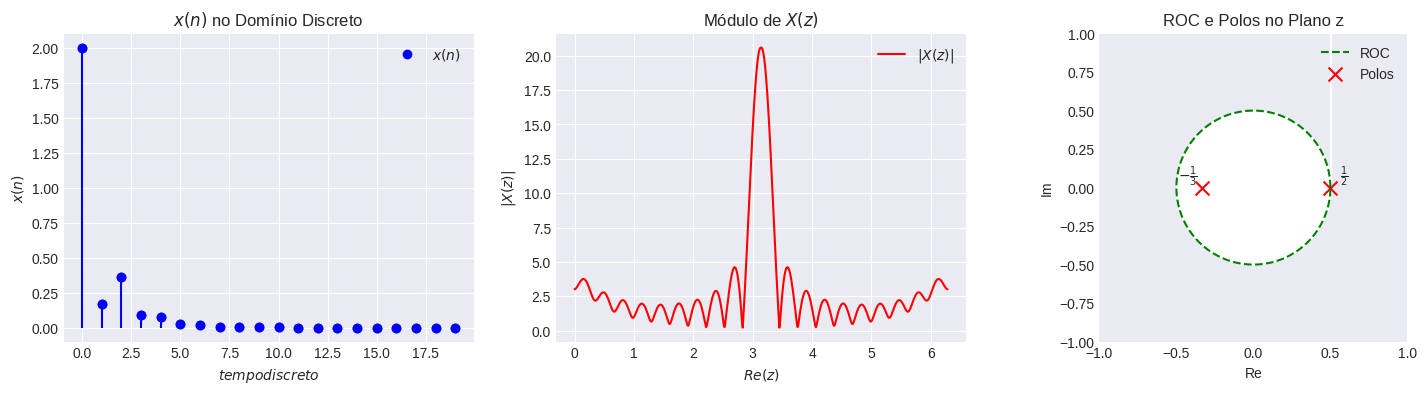

In [7]:
# Configurações para o gráfico
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Gráfico do sinal x(n) no tempo discreto
axes[0].plot(n.get(), x_n.get(), "o", color='blue', label='$x(n)$')
axes[0].stem(n.get(), x_n.get(), basefmt=" ", linefmt = "b")
axes[0].set_xlabel('$tempo discreto$')
axes[0].set_ylabel('$x(n)$')
axes[0].set_title('$x(n)$ no Domínio Discreto')
axes[0].legend(loc='best')

# Gráfico do módulo de X(z) no plano z (eixo real)
axes[1].plot(theta.get(), X_mod.get(), color='red', label='$|X(z)|$')
axes[1].set_xlabel('$Re(z)$')
axes[1].set_ylabel('$|X(z)|$')
axes[1].set_title('Módulo de $X(z)$')
axes[1].legend(loc='best')

# Gráfico da ROC e dos polos no plano z
axes[2].set_aspect('equal', 'box')
axes[2].plot(roc_circle.real, roc_circle.imag, 'g--', label='ROC')
axes[2].fill_between(roc_circle.real, roc_circle.imag, 2, color='white')
axes[2].grid()

# Posicionando os polos
axes[2].scatter([1/2, -1/3], [0, 0], color='red', label='Polos', marker='x', s=100)
axes[2].annotate('$\\frac{1}{2}$', (1/2, 0), textcoords="offset points", xytext=(10,5), ha='center')
axes[2].annotate('$-\\frac{1}{3}$', (-1/3, 0), textcoords="offset points", xytext=(-10,5), ha='center')

# Configurações finais do gráfico da ROC
axes[2].set_xlabel('Re')
axes[2].set_ylabel('Im')
axes[2].set_xlim(-1, 1)
axes[2].set_ylim(-1, 1)
axes[2].set_title('ROC e Polos no Plano z')
axes[2].legend()

plt.show()

### Transformada de Fourier Discreta **(DFT)**
---

Quando calculamos Transformada de Fourier em tempo discreto, percebemos que a representação no domínio da frequência depende da variável $(Ω \ ou \ ω)$, que é contínua. Para processamentos de sinais, precisamos de uma transformada que depende de uma variável discreta, para isso faremos um mapeamento chamado de Tranformada de Fourier Discreta __(DFT)__.

Como $X(e^{jw})$ é periódica com período de $2π$, é conveniente mostrar como um intervalo de amostra, tornando $N$ amostras uniforme neste período de $2\pi$ da transformada no tempo discreto. Esse processo de amostragem equivale a DFT $X'(e^{jw})$.

$$X'(e^{jw}) = X(e^{jw}) \ \sum_{k = -∞}^{∞} δ(ω - \frac{2π}{N}k)\ ⟺ \
x'n = x[n].\frac{N}{2π}\sum_{p = -∞}^{∞} δ(N - N_p)$$

Fazendo algumas alterações, chegamos a conclusão da expressão da **DFT**. Dada uma sequência $x(n), 0 < n < N - 1$, sua **DFT** é definida como:

$$\begin{equation}
  x(n) = \frac{1}{N} \sum_{k = 0}^{N - 1} X_k \ e^{j\frac{2π}{N}kn} \ ,
  \text{ para: $0 < n < N - 1$}
\end{equation}$$
$$\begin{equation}
  X_k = \sum_{k = 0}^{N - 1} x(n) \ e^{-j\frac{2π}{N}kn} \ ,
  \text{ para: $0 < k < N - 1$}
\end{equation}$$

Analisando a relação das frequências das **DFTs** variando entre $0Hz$ a $f_sHz$, temos:
$$ω = \frac{ω_s.k}{N} \ rad/s \ ⟹ \ f = \frac{f_s.k}{N} \ Hz \
⟹ \ Δω = \frac{ω_s}{N} \ rad/s \ ⟹ \ Δf = \frac{f_s}{N} Hz \ $$

Uma das aplicações da **DFT** é transformar um sinal digital de comprimento finito em domínio da frequência. Como cada coeficiente DFT calculado é um número complexo não convém plotar diretamente no domínio da frequência. Avaliando a amplitude e fase separadamente, podemos plotar o gráfico, assim temos:

+ *Amplitude:* $ \begin{equation}
  A_k = \frac{1}{N} \ |X(k)| \ = \ \frac{1}{N} \ \sqrt{(Re[X(k)])^2 + (Im[X(k)])^2}
\end{equation}$
+ *Fase:* $\begin{equation}
  Ø_k = arctg(\frac{Im}{Re})
\end{equation}$

Dividir por $N$ ajusta a escala do espectro de amplitude, garante que a amplitude do espectro seja proporcional ao sinal. Quando aplicamos a **DFT** pode ocorrer descontinuidade que produz frequências harmônicas indesejadas, essa descontinuidade pode ocorrer quando o tamanho da janela não é multiplo inteiro do período do sinal. Fazendo uns ajustes nos gráficos podemos melhorar as análises, a resolução do espectro e reduzir os ruídos.

### Transformada de Fourier rápida __(FFT)__

A __DFT__ é definida por uma soma que envolve todos os pontos do sinal de entrada e cada ponto do domínio de frequência contém uma conbinação linear de todos os pontos do sinal de origem. Isso resulta em um tipo de matriz ou função $N * N = N^2$, a complexidade da DFT cresce com o quadrado do comprimento do sinal.

Para solucionar essa limitação, foi desenvolvida a Transformação de Fourier rápida __(FFT)__ que reduz para ordem de $Nlog_2N$. A FFT utiliza uma abordagem de divisão e conquista, onde divide em partes menores, otimizando a forma dos cáculos.

Se a sequência $x[n]$ possui $N = 2^l$, a FFT quebra os somatório em duas partes, uma com os índices pares de $x[n]$ e outra com os índices ímpares de $x[n]$. A FFT possui vários algoritmos para resolução da DFT.

In [4]:
# Calculando o sinal de x(n).
def x_n(n, fs):
    return 2 * cp.sin(2000 * cp.pi * (n/fs))

def X_w(x_n, fs, N):
    fft = cp.fft.fft(x_n) / N
    return cp.abs(fft)

# Parametros para o sinal.
fs = 8000
N = 1000
n = cp.arange(0, N)

# Definindo os sinais.
freq = (n * fs) / N
x_n = x_n(n, fs)
X_w = X_w(x_n, fs, N)

x = cp.concatenate([x_n, cp.zeros(24)])
Nn = len(x)
nn = cp.arange(0, Nn)
freq_n = (nn * fs) / Nn
Xw_n = cp.abs(cp.fft.fft(x)) / Nn

# Transformando as variaveis em formato numpy para plotar.
x_n = x_n.get()
freq = freq.get()
X_w = X_w.get()
x = x.get()
freq_n = freq_n.get()
Xw_n = Xw_n.get()
n = n.get()

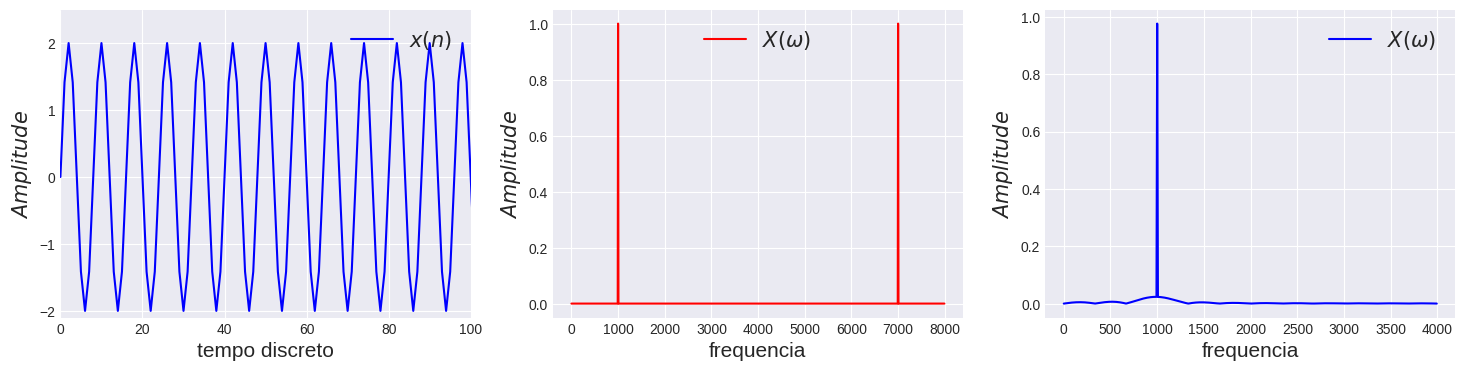

In [5]:
# Configurações para o gráfico
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plotando Gráfico de x(n).
axes[0].plot(n, x_n, color="blue", label="$x(n)$")
axes[0].set_xlim(0, 100)
axes[0].set_ylim(-2.1, 2.5)
axes[0].set_xlabel("tempo discreto", fontsize = 15)
axes[0].set_ylabel("$Amplitude$", fontsize = 15)
axes[0].legend(loc="upper right", fontsize = 15)

# Plotando Gráfico de X(w).
axes[1].plot(freq, X_w, color="red", label="$X(\omega)$")
axes[1].set_xlabel("frequencia", fontsize = 15)
axes[1].set_ylabel("$Amplitude$", fontsize = 15)
axes[1].legend(loc="best", fontsize = 15)

# Plotando Gráfico de X(w).
axes[2].plot(freq_n[: Nn // 2], Xw_n[: Nn // 2 ], color="blue", label="$X(\omega)$")
axes[2].set_xlabel("frequencia", fontsize = 15)
axes[2].set_ylabel("$Amplitude$", fontsize = 15)
axes[2].legend(loc="best", fontsize = 15)

plt.show()

### Referências:
---
1. **BROWN, J. W.; CHURCHILL, R. V.** *Complex Variables and Applications*. 8ª ed. New York: McGraw-Hill, 2009.
2. **Universidade Estadual de Campinas**. *Linearidade em Sinais e Sistemas*. Disponível em: [https://www.fee.unicamp.br/profs/peres/ia888/1s24/ia888_1s24.html](https://www.fee.unicamp.br/profs/peres/ia888/1s24/ia888_1s24.html). Acessado em 29 de Outubro de 2024.
3. **OPPENHEIM, A. V.; WILLSKY, A. S.** *Signals and Systems*. 2ª ed. New Jersey: Prentice Hall, 1997.
4. **Francinildo Figueiredo**. *Desempenho de Equalizadores adaptativos*. Disponível em: [https://github.com/edsonportosilva/Repositorio-PIBIC-2022](https://github.com/edsonportosilva/Repositorio-PIBIC-2022). Acessado em: 30 de outubro de 2024
5. **Tan, L., & Jiang, J.**. *Digital Signal Processing: Fundamentals and Applications*. 3ª Edição. AP, 2019
6. **Diniz, P. S. R., Silva, E. A. B. da, & Netto, S. L.**. *Processamento Digital de Sinais: Projeto e Análise de Sistemas*. 2ª Edição. Bookman, 2014
7. **Eric Brandão**. *Processamento de sinais - Transformada Discreta Fourier*. Disponível em: [https://youtube.com/playlist?list=PLfuiSoAvtFWdDiWmUxA1jIsNEbwZCbyvB&si=NIVv3WkGTYoQX9Sw](https://youtube.com/playlist?list=PLfuiSoAvtFWdDiWmUxA1jIsNEbwZCbyvB&si=NIVv3WkGTYoQX9Sw). Acessado em 11 de Novembro de 2024.
